In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set plot style
sns.set(style="whitegrid")
plt.style.use('ggplot')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 1. Load the full dataset to ensure 'InvoiceNo' is included
df_path = 'data/Online_Retail.xlsx'
df = pd.read_excel(df_path, dtype={'InvoiceNo': str, 'StockCode': str}) # Reading InvoiceNo as string
print(f"Successfully loaded original dataset with shape: {df.shape}")

# 2. Perform all cleaning steps
# Remove records with missing CustomerID [cite: 15]
df.dropna(subset=['CustomerID'], inplace=True)
# Convert CustomerID to integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Filter for United Kingdom only [cite: 16]
df_uk = df[df['Country'] == 'United Kingdom'].copy()

# Remove cancelled orders (InvoiceNo starts with 'C') [cite: 17]
df_uk = df_uk[~df_uk['InvoiceNo'].str.startswith('C', na=False)]

# Remove transactions with non-positive quantity or zero price
df_uk = df_uk[(df_uk['Quantity'] > 0) & (df_uk['UnitPrice'] > 0)]

# 3. Final preparation for RFM
# Convert InvoiceDate to datetime
df_uk['InvoiceDate'] = pd.to_datetime(df_uk['InvoiceDate'])
# Create TotalPrice column
df_uk['TotalPrice'] = df_uk['Quantity'] * df_uk['UnitPrice']


print(f"Final shape of the cleaned dataset: {df_uk.shape}")
print("\n--- Corrected DataFrame Info ---")
df_uk.info()
print("\n--- Corrected DataFrame Head ---")
display(df_uk.head())

Successfully loaded original dataset with shape: (541909, 8)
Final shape of the cleaned dataset: (354321, 9)

--- Corrected DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 354321 entries, 0 to 541893
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    354321 non-null  object        
 1   StockCode    354321 non-null  object        
 2   Description  354321 non-null  object        
 3   Quantity     354321 non-null  int64         
 4   InvoiceDate  354321 non-null  datetime64[ns]
 5   UnitPrice    354321 non-null  float64       
 6   CustomerID   354321 non-null  int64         
 7   Country      354321 non-null  object        
 8   TotalPrice   354321 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 27.0+ MB

--- Corrected DataFrame Head ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [3]:
# Set a snapshot date for recency calculation (one day after the last transaction in the dataset)
snapshot_date = df_uk['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date for Recency calculation: {snapshot_date}")

# Group by CustomerID and calculate RFM metrics
rfm = df_uk.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename the columns to be more descriptive
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'InvoiceNo': 'Frequency',
                    'TotalPrice': 'Monetary'}, inplace=True)

print("\nRFM table created successfully!")
display(rfm.head())

# Check the distribution of the RFM values
print("\nDescription of the RFM table:")
display(rfm.describe())

Snapshot date for Recency calculation: 2011-12-10 12:49:00

RFM table created successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12747,2,11,4196.01
12748,1,209,33719.73
12749,4,5,4090.88
12820,3,4,942.34



Description of the RFM table:


,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000
mean,92.208418,4.246429,1864.385601
std,99.533854,7.199202,7482.817477
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,300.280000
50%,51.000000,2.000000,652.280000
75%,143.000000,5.000000,1576.585000
max,374.000000,209.000000,259657.300000


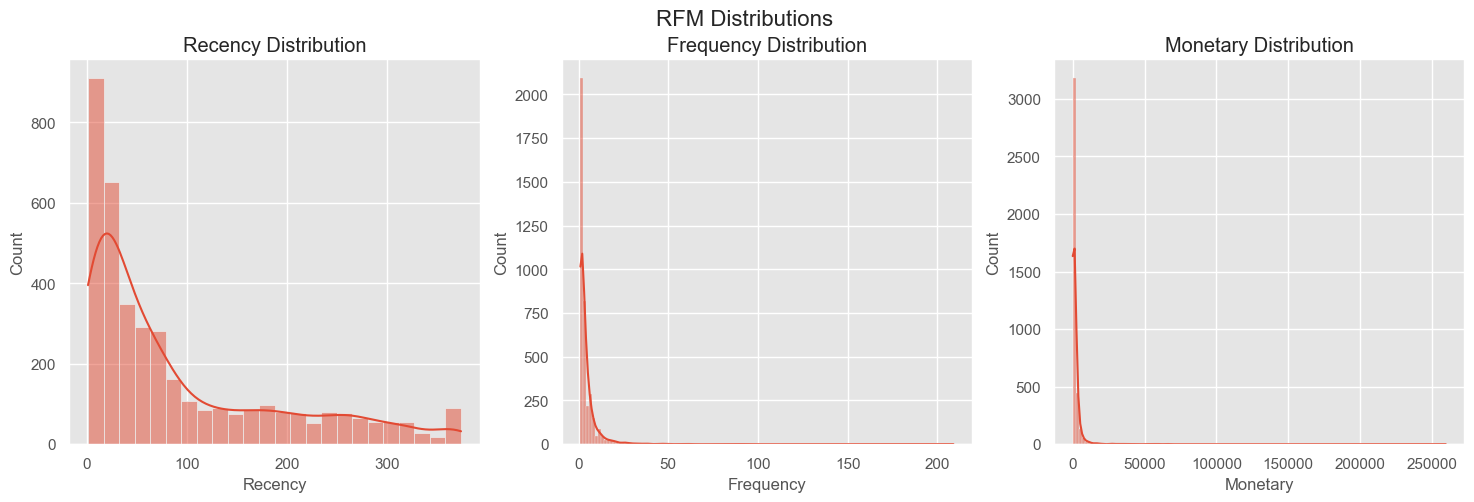

Data has been log-transformed and standardized.

--- First 5 rows of the scaled RFM data ---


,Recency,Frequency,Monetary
CustomerID,,,
12346,2.349165,-0.451000,10.066906
12747,-0.906425,0.938220,0.311637
12748,-0.916473,28.444775,4.257675
12749,-0.886328,0.104688,0.297586
12820,-0.896376,-0.034234,-0.123237


In [4]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- 1. Visualize the distributions before transformation ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm['Recency'], ax=axes[0], kde=True).set_title('Recency Distribution')
sns.histplot(rfm['Frequency'], ax=axes[1], kde=True).set_title('Frequency Distribution')
sns.histplot(rfm['Monetary'], ax=axes[2], kde=True).set_title('Monetary Distribution')
plt.suptitle('RFM Distributions', fontsize=16)
plt.show()

'''
# --- 2. Apply Logarithmic Transformation to handle skewness ---
# We add 1 to avoid log(0) issues if any value is zero
rfm_log = np.log(rfm + 1)


# --- 3. Visualize the distributions after transformation ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm_log['Recency'], ax=axes[0], kde=True).set_title('Recency (Log Transformed)')
sns.histplot(rfm_log['Frequency'], ax=axes[1], kde=True).set_title('Frequency (Log Transformed)')
sns.histplot(rfm_log['Monetary'], ax=axes[2], kde=True).set_title('Monetary (Log Transformed)')
plt.suptitle('RFM Distributions After Log Transformation', fontsize=16)
plt.show()
'''

# --- 4. Standardize the log-transformed data ---
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Convert the scaled array back to a DataFrame
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("Data has been log-transformed and standardized.")
print("\n--- First 5 rows of the scaled RFM data ---")
display(rfm_scaled_df.head())

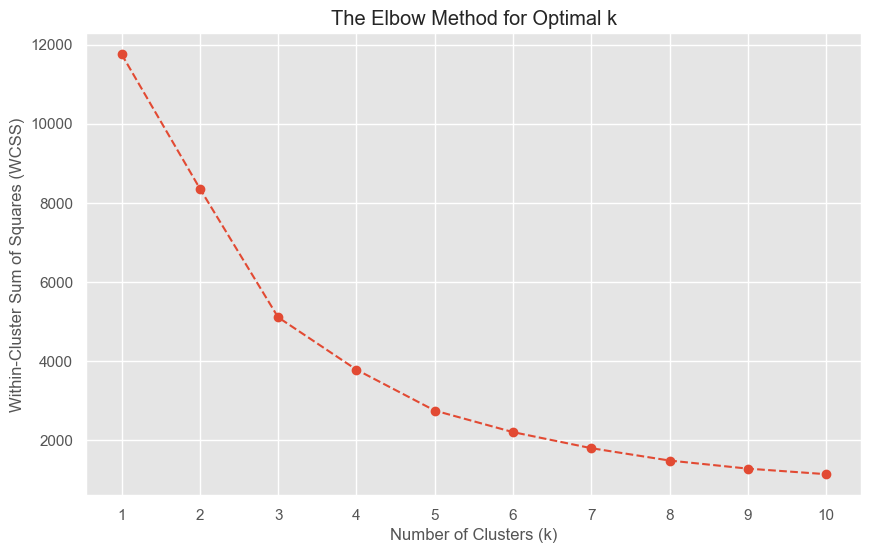

In [5]:
from sklearn.cluster import KMeans

# Calculate WCSS for a range of k values
wcss = []
k_range = range(1, 11)  # We will test k from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_) # inertia_ is the WCSS value

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('The Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [6]:
# Set the optimal number of clusters
optimal_k = 5

# Initialize and fit the K-Means model
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled_df)

# Add the cluster labels to the original unscaled RFM dataframe for interpretation
rfm['Cluster'] = cluster_labels

# Add the cluster labels to the scaled dataframe as well
rfm_scaled_df['Cluster'] = cluster_labels

print(f"Successfully applied K-Means with k={optimal_k}.")
print("\n--- RFM table with assigned clusters ---")
display(rfm.head())

# Check the size of each cluster
print("\n--- Cluster Sizes ---")
print(rfm['Cluster'].value_counts())

Successfully applied K-Means with k=5.

--- RFM table with assigned clusters ---


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,3
12747,2,11,4196.01,3
12748,1,209,33719.73,2
12749,4,5,4090.88,1
12820,3,4,942.34,1



--- Cluster Sizes ---
Cluster
1    2646
0     963
3     289
2      19
4       3
Name: count, dtype: int64


--- Mean RFM Values for Each Cluster ---


,Recency,Frequency,Monetary
Cluster,,,
0,246.99,1.56,437.88
1,44.74,3.33,1140.04
2,5.79,66.79,49710.91
3,17.62,17.13,7968.78
4,3.33,36.00,207560.20


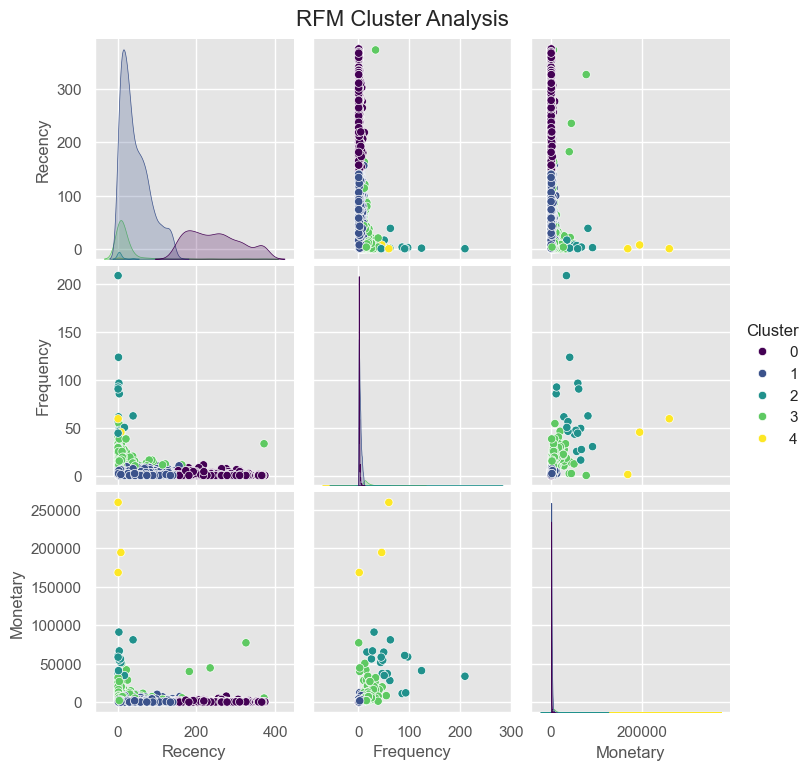

In [7]:
# Calculate the mean RFM values for each cluster
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print("--- Mean RFM Values for Each Cluster ---")
display(cluster_analysis)

# --- Visualize the clusters ---
# We can use a pairplot to see the separation
sns.pairplot(rfm, hue='Cluster', vars=['Recency', 'Frequency', 'Monetary'], palette='viridis')
plt.suptitle('RFM Cluster Analysis', y=1.02, fontsize=16)
plt.show()

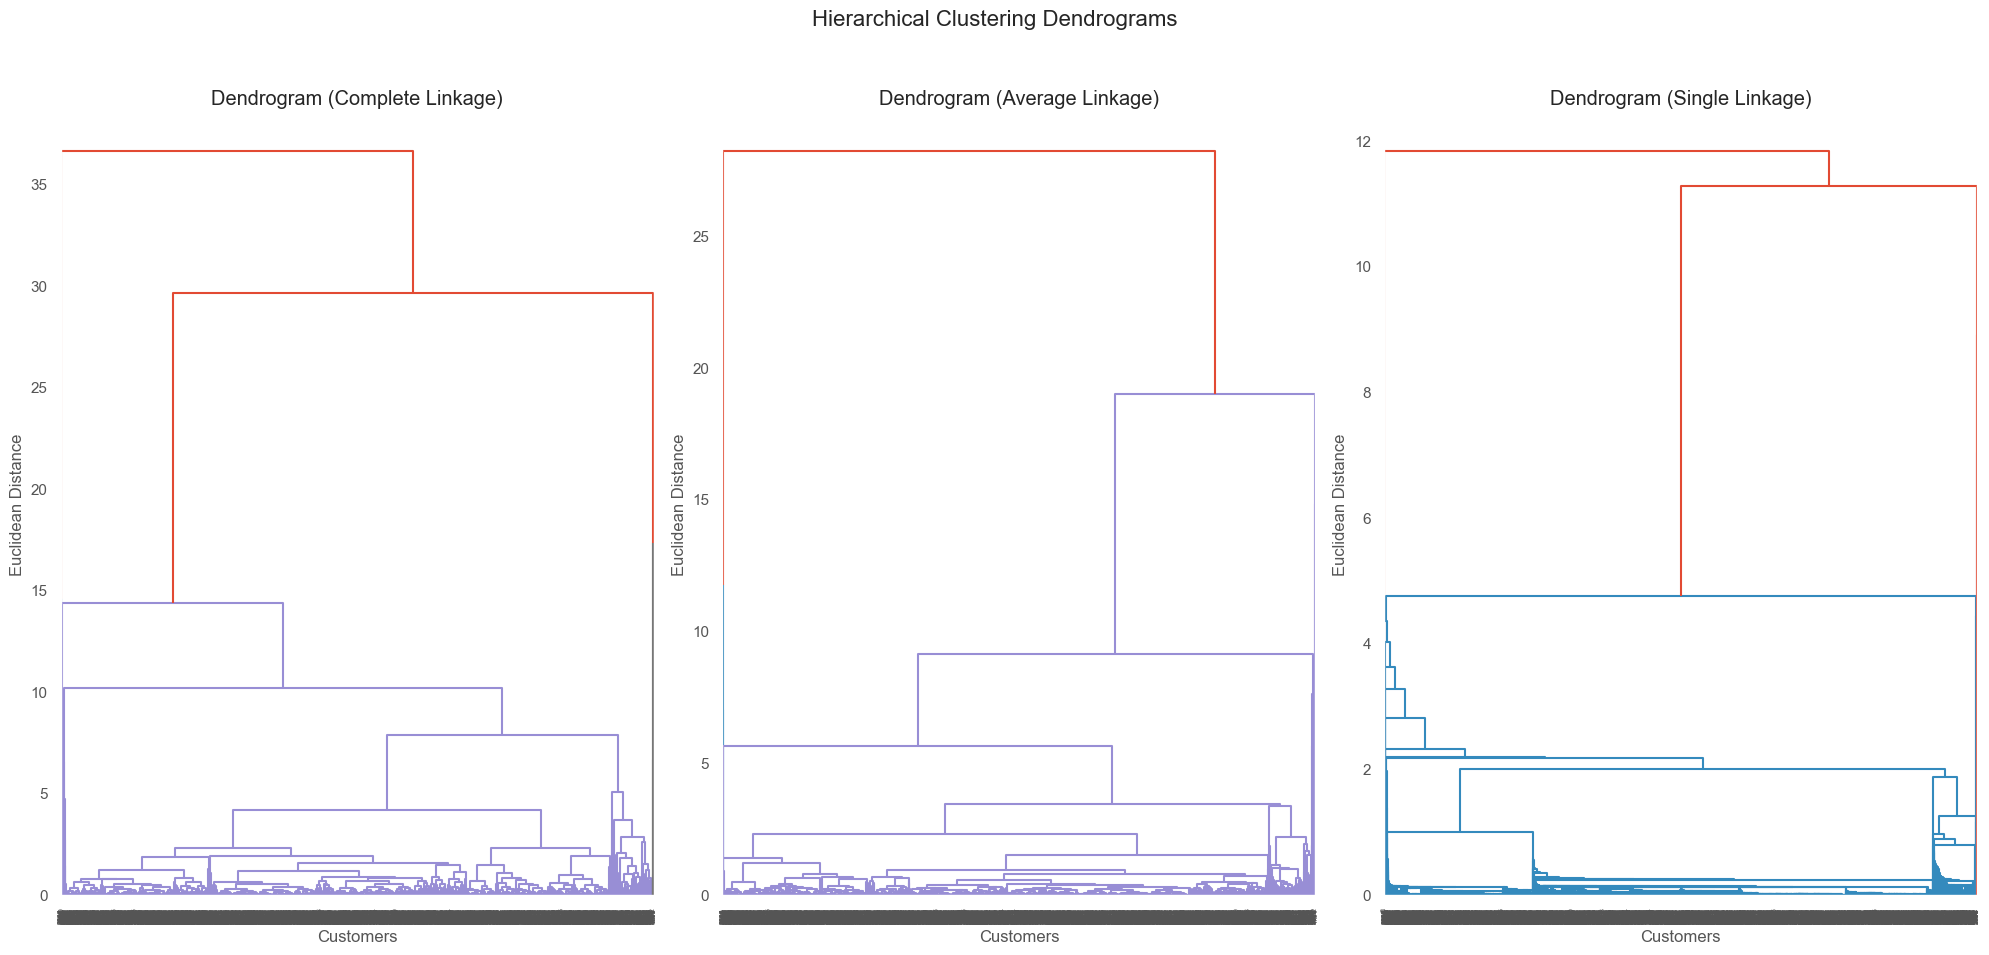

In [8]:
import scipy.cluster.hierarchy as sch

# --- Generate Dendrograms for Different Linkage Methods ---
plt.figure(figsize=(20, 10))

# 1. Complete Linkage
plt.subplot(1, 3, 1)
plt.title('Dendrogram (Complete Linkage)')
dend_complete = sch.dendrogram(sch.linkage(rfm_scaled_df, method='complete'))
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')

# 2. Average Linkage
plt.subplot(1, 3, 2)
plt.title('Dendrogram (Average Linkage)')
dend_average = sch.dendrogram(sch.linkage(rfm_scaled_df, method='average'))
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')

# 3. Single Linkage
plt.subplot(1, 3, 3)
plt.title('Dendrogram (Single Linkage)')
dend_single = sch.dendrogram(sch.linkage(rfm_scaled_df, method='single'))
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')

plt.suptitle('Hierarchical Clustering Dendrograms', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
from sklearn.cluster import AgglomerativeClustering

# Initialize and fit the Agglomerative Clustering model
agg_cluster = AgglomerativeClustering(n_clusters=4, linkage='complete')
hc_labels = agg_cluster.fit_predict(rfm_scaled_df)

# Add the hierarchical cluster labels to our original rfm dataframe
rfm['HC_Cluster'] = hc_labels

print("Successfully applied Hierarchical Clustering.")

# Calculate the mean RFM values for each cluster
hc_cluster_analysis = rfm.groupby('HC_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print("\n--- Mean RFM Values for Each Hierarchical Cluster ---")
display(hc_cluster_analysis)

Successfully applied Hierarchical Clustering.

--- Mean RFM Values for Each Hierarchical Cluster ---


,Recency,Frequency,Monetary
HC_Cluster,,,
0,3.33,36.00,207560.20
1,2.20,98.20,36786.37
2,92.41,4.05,1653.81
3,1.00,209.00,33719.73


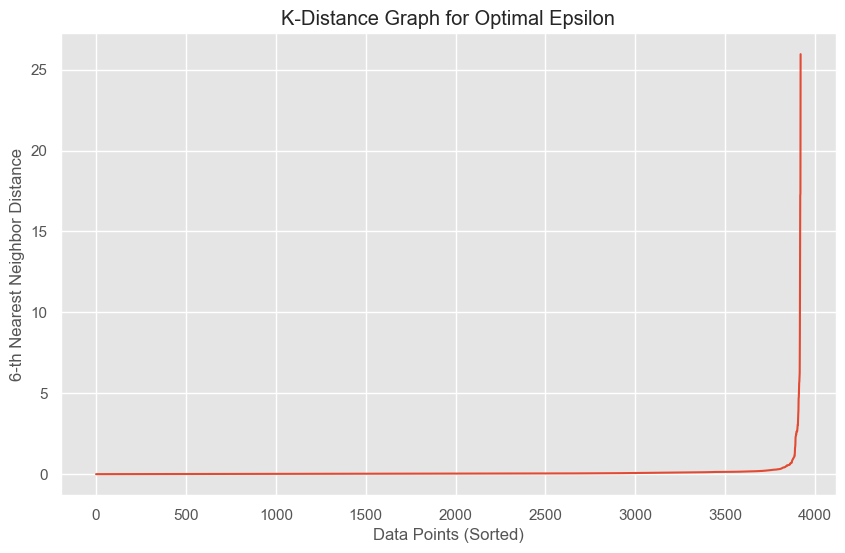

In [10]:
from sklearn.neighbors import NearestNeighbors

# Calculate the distance from each point to its nearest neighbors
# We set n_neighbors to our chosen min_samples value
min_samples = 6
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(rfm_scaled_df)
distances, indices = neighbors_fit.kneighbors(rfm_scaled_df)

# Sort the distances to the k-th neighbor (k = min_samples)
k_distances = sorted(distances[:, min_samples-1])

# Plot the k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.title('K-Distance Graph for Optimal Epsilon')
plt.xlabel('Data Points (Sorted)')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

Successfully applied DBSCAN clustering.

Estimated number of clusters: 3
Estimated number of noise points: 62


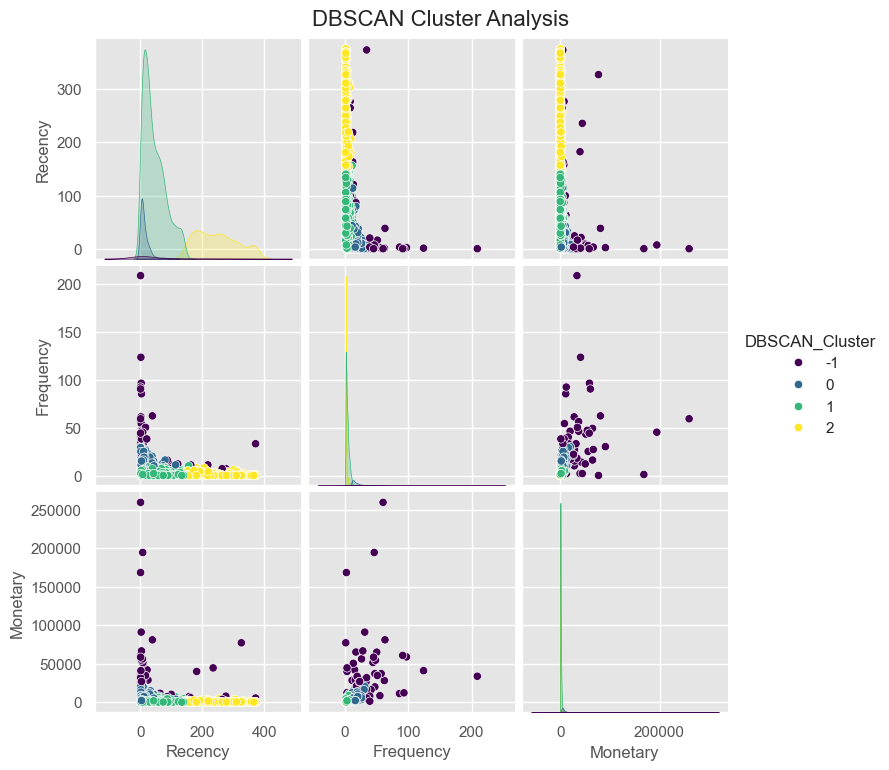

In [11]:
from sklearn.cluster import DBSCAN

# Initialize and run the DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=6)
dbscan_labels = dbscan.fit_predict(rfm_scaled_df)

# Add the DBSCAN cluster labels to our rfm dataframe
rfm['DBSCAN_Cluster'] = dbscan_labels

print("Successfully applied DBSCAN clustering.")

# --- Analyze the results ---
# Get the number of clusters (excluding noise, which is labeled -1)
n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_ = list(dbscan_labels).count(-1)

print(f"\nEstimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

# --- Visualize the clusters ---
# Note: Noise points will be plotted in a distinct color
sns.pairplot(rfm, hue='DBSCAN_Cluster', vars=['Recency', 'Frequency', 'Monetary'], palette='viridis')
plt.suptitle('DBSCAN Cluster Analysis', y=1.02, fontsize=16)
plt.show()

In [12]:
from sklearn.metrics import silhouette_score

# The dataframe with the scaled data (no cluster columns)
data_for_scoring = rfm_scaled_df.drop('Cluster', axis=1)

# --- 1. K-Means Silhouette Score ---
kmeans_silhouette = silhouette_score(data_for_scoring, rfm['Cluster'])
print(f"K-Means Silhouette Score: {kmeans_silhouette:.3f}")


# --- 2. Hierarchical Clustering Silhouette Score ---
hc_silhouette = silhouette_score(data_for_scoring, rfm['HC_Cluster'])
print(f"Hierarchical Clustering Silhouette Score: {hc_silhouette:.3f}")


# --- 3. DBSCAN Silhouette Score ---
# We must remove noise points (-1) before calculating the score
dbscan_mask = rfm['DBSCAN_Cluster'] != -1

# Filter both the data and the labels to exclude noise
dbscan_data_filtered = data_for_scoring[dbscan_mask]
dbscan_labels_filtered = rfm[dbscan_mask]['DBSCAN_Cluster']

# Check if there's more than one cluster after filtering noise
if len(set(dbscan_labels_filtered)) > 1:
    dbscan_silhouette = silhouette_score(dbscan_data_filtered, dbscan_labels_filtered)
    print(f"DBSCAN Silhouette Score (excluding noise): {dbscan_silhouette:.3f}")
else:
    print("DBSCAN found only one cluster (or all noise), so Silhouette Score cannot be calculated.")

K-Means Silhouette Score: 0.601
Hierarchical Clustering Silhouette Score: 0.893
DBSCAN Silhouette Score (excluding noise): 0.596
